In [15]:
import corner
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib
from gwpy.timeseries import TimeSeries
import math
import bilby
from bilby.gw.conversion import generate_all_bbh_parameters
from bilby.core import utils
import numpy as np
from gwosc import datasets
import h5py
import pesummary
from pesummary.io import read
from pesummary.core.plots.plot import _make_comparison_corner_plot
import seaborn as sns
import pandas as pd
import itertools
import argparse
import warnings
import os
import json
import configparser
import errno

plt.style.use('~/research/my_plot_style.style')

def calculate_resolvability_of_complex_frequencies_bilby(json_file_path, percentiles=[16, 84]):
    data = read(json_file_path, package='core')
    posterior_samples = data.samples_dict.to_pandas()
    injection_parameters_dict = data.injection_parameters

    if 'delta_f' in posterior_samples.columns:
        posterior_samples['f2'] = posterior_samples['f1'] + posterior_samples['delta_f']
        injection_parameters_dict['f2'] = injection_parameters_dict['f1'] + injection_parameters_dict['delta_f']
    if 'delta_tau' in posterior_samples.columns:
        posterior_samples['tau2'] = posterior_samples['tau1'] + posterior_samples['delta_tau']
        injection_parameters_dict['tau2'] = injection_parameters_dict['tau1'] + injection_parameters_dict['delta_tau']
    
    f1_samples = posterior_samples['f1']
    f2_samples = posterior_samples['f2']
    tau1_samples = posterior_samples['tau1']
    tau2_samples = posterior_samples['tau2']
    f1_inj = injection_parameters_dict['f1']
    f2_inj = injection_parameters_dict['f2']
    tau1_inj = injection_parameters_dict['tau1']
    tau2_inj = injection_parameters_dict['tau2']

    w1 = 2 * np.pi * f1_inj + 1j / tau1_inj
    w2 = 2 * np.pi * f2_inj + 1j / tau2_inj
    delta_w = w1 - w2
    dw_over_w1 = np.abs(delta_w) / np.abs(w1)

    if not f1_inj == f2_inj:
        sigma_f1 = np.percentile(f1_samples, percentiles[1]) - np.percentile(f1_samples, percentiles[0])
        sigma_f2 = np.percentile(f2_samples, percentiles[1]) - np.percentile(f2_samples, percentiles[0])
        delta_f = np.abs(f1_inj - f2_inj)
        resolvability_f = np.max([sigma_f1, sigma_f2]) / delta_f
    else:
        resolvability_f = None

    if not tau1_inj == tau2_inj:
        sigma_tau1 = np.percentile(tau1_samples, percentiles[1]) - np.percentile(tau1_samples, percentiles[0])
        sigma_tau2 = np.percentile(tau2_samples, percentiles[1]) - np.percentile(tau2_samples, percentiles[0])
        delta_tau = np.abs(tau1_inj - tau2_inj)
        resolvability_tau = np.max([sigma_tau1, sigma_tau2]) / delta_tau
    else:
        resolvability_tau = None

    print('-------------------------')
    print(f"|dw/w1|: {dw_over_w1}")
    print(f"Resolvability in frequency: {resolvability_f}")
    print(f"Resolvability in time: {resolvability_tau}")

    fractional_accuracy_f1 = np.abs(np.percentile(f1_samples, 50) - f1_inj) / np.abs(f1_inj)
    fractional_accuracy_f2 = np.abs(np.percentile(f2_samples, 50) - f2_inj) / np.abs(f2_inj)
    fractional_accuracy_tau1 = np.abs(np.percentile(tau1_samples, 50) - tau1_inj) / np.abs(tau1_inj)
    fractional_accuracy_tau2 = np.abs(np.percentile(tau2_samples, 50) - tau2_inj) / np.abs(tau2_inj)
    print(f"Fractional accuracy in f1: {fractional_accuracy_f1}")
    print(f"Fractional accuracy in f2: {fractional_accuracy_f2}")
    print(f"Fractional accuracy in tau1: {fractional_accuracy_tau1}")
    print(f"Fractional accuracy in tau2: {fractional_accuracy_tau2}")

    dw_samples = 2 * np.pi * (f2_samples - f1_samples) + 1j * (1 / tau2_samples - 1 / tau1_samples)
    dw_inj = 2 * np.pi * (f2_inj - f1_inj) + 1j * (1 / tau2_inj - 1 / tau1_inj)
    fractional_accuracy_dw = np.abs(np.percentile(np.abs(dw_samples), 50) - np.abs(dw_inj)) / np.abs(dw_inj)
    print(f"Fractional accuracy in dw: {fractional_accuracy_dw}")
    print('-------------------------')

    result_dict = {
        'dw_over_w1': dw_over_w1,
        'resolvability_f': resolvability_f,
        'resolvability_tau': resolvability_tau,
        'fractional_accuracy_f1': fractional_accuracy_f1,
        'fractional_accuracy_f2': fractional_accuracy_f2,
        'fractional_accuracy_tau1': fractional_accuracy_tau1,
        'fractional_accuracy_tau2': fractional_accuracy_tau2,
        'fractional_accuracy_dw': fractional_accuracy_dw
    }
    return result_dict

def calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample, path_config, percentiles=[16, 84]):
    """load posterior sample"""
    posterior_samples = pd.read_csv(path_posterior_sample, sep='\s+')
    if '#' in posterior_samples.columns:
        if posterior_samples.iloc[:, -1].isna().all():
            real_columns = posterior_samples.columns[1:].tolist()
            posterior_samples = posterior_samples.iloc[:, :-1]
            posterior_samples.columns = change_param_name(real_columns)
    print(posterior_samples.columns)

    """load injection parameters"""
    config_ini = configparser.ConfigParser()
    config_ini.optionxform = str
    config_ini.read(path_config, encoding='utf-8')
    if not os.path.exists(path_config):
        raise FileNotFoundError(errno.ENOENT, os.strerror(errno.ENOENT), path_config)
    config_injection = config_ini['Injection']
    injection_parameters_dict = {}
    injection_param_key_new = change_param_name(config_injection.keys())
    for key, val in zip(injection_param_key_new, config_injection.values()):
        injection_parameters_dict[key] = float(val)
    print(injection_parameters_dict)

    if 'delta_f' in posterior_samples.columns:
        posterior_samples['f2'] = posterior_samples['f1'] + posterior_samples['delta_f']
        injection_parameters_dict['f2'] = injection_parameters_dict['f1'] + injection_parameters_dict['delta_f']
    if 'delta_tau' in posterior_samples.columns:
        posterior_samples['tau2'] = posterior_samples['tau1'] + posterior_samples['delta_tau']
        injection_parameters_dict['tau2'] = injection_parameters_dict['tau1'] + injection_parameters_dict['delta_tau']
    
    f1_samples = posterior_samples['f1']
    f2_samples = posterior_samples['f2']
    tau1_samples = posterior_samples['tau1']
    tau2_samples = posterior_samples['tau2']
    f1_inj = injection_parameters_dict['f1']
    f2_inj = injection_parameters_dict['f2']
    tau1_inj = injection_parameters_dict['tau1']
    tau2_inj = injection_parameters_dict['tau2']

    w1 = 2 * np.pi * f1_inj + 1j / tau1_inj
    w2 = 2 * np.pi * f2_inj + 1j / tau2_inj
    delta_w = w1 - w2
    dw_over_w1 = np.abs(delta_w) / np.abs(w1)

    if not f1_inj == f2_inj:
        sigma_f1 = np.percentile(f1_samples, percentiles[1]) - np.percentile(f1_samples, percentiles[0])
        sigma_f2 = np.percentile(f2_samples, percentiles[1]) - np.percentile(f2_samples, percentiles[0])
        delta_f = np.abs(f1_inj - f2_inj)
        resolvability_f = np.max([sigma_f1, sigma_f2]) / delta_f
    else:
        resolvability_f = None

    if not tau1_inj == tau2_inj:
        sigma_tau1 = np.percentile(tau1_samples, percentiles[1]) - np.percentile(tau1_samples, percentiles[0])
        sigma_tau2 = np.percentile(tau2_samples, percentiles[1]) - np.percentile(tau2_samples, percentiles[0])
        delta_tau = np.abs(tau1_inj - tau2_inj)
        resolvability_tau = np.max([sigma_tau1, sigma_tau2]) / delta_tau
    else:
        resolvability_tau = None

    print('-------------------------')
    print(f"|dw/w1|: {dw_over_w1}")
    print(f"Resolvability in frequency: {resolvability_f}")
    print(f"Resolvability in time: {resolvability_tau}")

    fractional_accuracy_f1 = np.abs(np.percentile(f1_samples, 50) - f1_inj) / np.abs(f1_inj)
    fractional_accuracy_f2 = np.abs(np.percentile(f2_samples, 50) - f2_inj) / np.abs(f2_inj)
    fractional_accuracy_tau1 = np.abs(np.percentile(tau1_samples, 50) - tau1_inj) / np.abs(tau1_inj)
    fractional_accuracy_tau2 = np.abs(np.percentile(tau2_samples, 50) - tau2_inj) / np.abs(tau2_inj)
    print(f"Fractional accuracy in f1: {fractional_accuracy_f1}")
    print(f"Fractional accuracy in f2: {fractional_accuracy_f2}")
    print(f"Fractional accuracy in tau1: {fractional_accuracy_tau1}")
    print(f"Fractional accuracy in tau2: {fractional_accuracy_tau2}")

    dw_samples = 2 * np.pi * (f2_samples - f1_samples) + 1j * (1 / tau2_samples - 1 / tau1_samples)
    dw_inj = 2 * np.pi * (f2_inj - f1_inj) + 1j * (1 / tau2_inj - 1 / tau1_inj)
    fractional_accuracy_dw = np.abs(np.percentile(np.abs(dw_samples), 50) - np.abs(dw_inj)) / np.abs(dw_inj)
    print(f"Fractional accuracy in dw: {fractional_accuracy_dw}")
    print('-------------------------')

    result_dict = {
        'dw_over_w1': dw_over_w1,
        'resolvability_f': resolvability_f,
        'resolvability_tau': resolvability_tau,
        'fractional_accuracy_f1': fractional_accuracy_f1,
        'fractional_accuracy_f2': fractional_accuracy_f2,
        'fractional_accuracy_tau1': fractional_accuracy_tau1,
        'fractional_accuracy_tau2': fractional_accuracy_tau2,
        'fractional_accuracy_dw': fractional_accuracy_dw
    }
    return result_dict

def change_param_name(param_name_list):
    return_list = []
    for param_name in param_name_list:
        if '_t_0' in param_name:
            param = param_name.replace('_t_0', '1')
        elif '_t_1' in param_name:
            param = param_name.replace('_t_1', '2')
        else:
            param = param_name
        return_list.append(param)
    return return_list

In [16]:
# DS_Mirror_label_list = [
#                 'shiftRe_to_220_dw0.1w1_snr100_DSparam_Mirror',
#                 'shiftRe_to_220_dw0.01w1_snr100_DSparam_Mirror',
#                 'shiftRe_to_220_dw0.001w1_snr100_DSparam_Mirror',
#                 'shiftIm_to_220_dw0.1w1_snr100_DSparam_Mirror',
#                 'shiftIm_to_220_dw0.01w1_snr100_DSparam_Mirror',
#                 'shiftIm_to_220_dw0.001w1_snr100_DSparam_Mirror',
#                 ]

# DS_Heaviside_label_list = [
#                 'shiftRe_to_220_dw0.1w1_snr100_DSparam_Heaviside',
#                 'shiftRe_to_220_dw0.01w1_snr100_DSparam_Heaviside',
#                 'shiftRe_to_220_dw0.001w1_snr100_DSparam_Heaviside',
#                 'shiftIm_to_220_dw0.1w1_snr100_DSparam_Heaviside',
#                 'shiftIm_to_220_dw0.01w1_snr100_DSparam_Heaviside',
#                 'shiftIm_to_220_dw0.001w1_snr100_DSparam_Heaviside',
#                 ]

# OT_label_list = [
#                 'shiftRe_to_220_dw0.1w1_snr100_OTparam_v3',
#                 'shiftRe_to_220_dw0.01w1_snr100_OTparam_v3',
#                 'shiftRe_to_220_dw0.001w1_snr100_OTparam_v3',
#                 'shiftIm_to_220_dw0.1w1_snr100_OTparam_v3',
#                 'shiftIm_to_220_dw0.01w1_snr100_OTparam_v3',
#                 'shiftIm_to_220_dw0.001w1_snr100_OTparam_v3',
#                 ]
# OT_conditional_label_list = [
#                 'shiftRe_to_220_dw0.1w1_snr100_OTparam_f2_conditional',
#                 'shiftRe_to_220_dw0.01w1_snr100_OTparam_f2_conditional',
#                 'shiftRe_to_220_dw0.001w1_snr100_OTparam_f2_conditional',
#                 'shiftIm_to_220_dw0.1w1_snr100_OTparam_tau2_conditional',
#                 'shiftIm_to_220_dw0.01w1_snr100_OTparam_tau2_conditional',
#                 'shiftIm_to_220_dw0.001w1_snr100_OTparam_tau2_conditional',
#                 ]
# OTRA_label_list = [
#                 'shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp',
#                 'shiftRe_to_220_dw0.01w1_snr100_OTparam_real_amp',
#                 'shiftRe_to_220_dw0.001w1_snr100_OTparam_real_amp',
#                 'shiftIm_to_220_dw0.1w1_snr100_OTparam_real_amp',
#                 'shiftIm_to_220_dw0.01w1_snr100_OTparam_real_amp',
#                 'shiftIm_to_220_dw0.001w1_snr100_OTparam_real_amp',
#                 ]
# OTRA_conditional_label_list = [
#                 'shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp_f2_conditional',
#                 'shiftRe_to_220_dw0.01w1_snr100_OTparam_real_amp_f2_conditional',
#                 'shiftRe_to_220_dw0.001w1_snr100_OTparam_real_amp_f2_conditional',
#                 'shiftIm_to_220_dw0.1w1_snr100_OTparam_real_amp_tau2_conditional',
#                 'shiftIm_to_220_dw0.01w1_snr100_OTparam_real_amp_tau2_conditional',
#                 'shiftIm_to_220_dw0.001w1_snr100_OTparam_real_amp_tau2_conditional',
#                 ]

# DS_Mirror_result_list = []
# DS_Heaviside_result_list = []
# OT_result_list = []
# OT_conditional_result_list = []
# OTRA_result_list = []
# OTRA_conditional_result_list = []

# for label in DS_Mirror_label_list:
#     json_file_path_DS = f'./outdirs/outdir_{label}/{label}_result.json'
#     DS_Mirror_result_list.append(calculate_resolvability_of_complex_frequencies_bilby(json_file_path_DS))
# print('')

# for label in DS_Heaviside_label_list:
#     json_file_path_DS = f'./outdirs/outdir_{label}/{label}_result.json'
#     DS_Heaviside_result_list.append(calculate_resolvability_of_complex_frequencies_bilby(json_file_path_DS))
# print('')

# for label in OT_label_list:
#     json_file_path_OT = f'./outdirs/outdir_{label}/{label}_result.json'
#     OT_result_list.append(calculate_resolvability_of_complex_frequencies_bilby(json_file_path_OT))

# for label in OT_conditional_label_list:
#     json_file_path_OT_conditional = f'./outdirs/outdir_{label}/{label}_result.json'
#     OT_conditional_result_list.append(calculate_resolvability_of_complex_frequencies_bilby(json_file_path_OT_conditional))

# for label in OTRA_label_list:
#     json_file_path_OTRA = f'./outdirs/outdir_{label}/{label}_result.json'
#     OTRA_result_list.append(calculate_resolvability_of_complex_frequencies_bilby(json_file_path_OTRA))

# for label in OTRA_conditional_label_list:
#     json_file_path_OTRA_conditional = f'./outdirs/outdir_{label}/{label}_result.json'
#     OTRA_conditional_result_list.append(calculate_resolvability_of_complex_frequencies_bilby(json_file_path_OTRA_conditional))

DS_label_list = [
                'pyring_shiftRe_to_220_dw0.1w1_snr100_DSparam',
                'pyring_shiftRe_to_220_dw0.01w1_snr100_DSparam',
                'pyring_shiftRe_to_220_dw0.001w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.1w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.01w1_snr100_DSparam',
                'pyring_shiftIm_to_220_dw0.001w1_snr100_DSparam',
                ]

OT_label_list = [
                'pyring_shiftRe_to_220_dw0.1w1_snr100_OTparam',
                'pyring_shiftRe_to_220_dw0.01w1_snr100_OTparam',
                'pyring_shiftRe_to_220_dw0.001w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.1w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.01w1_snr100_OTparam',
                'pyring_shiftIm_to_220_dw0.001w1_snr100_OTparam',
                ]

DS_result_list_pyring = []
OT_result_list_pyring = []

for label in DS_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    DS_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

for label in OT_label_list:
    path_posterior = f'./run_pyring/outdirs/outdir_{label}/Nested_sampler/posterior.dat'
    config_file_path = f'./run_pyring/outdirs/outdir_{label}/{label}.ini'
    OT_result_list_pyring.append(calculate_resolvability_of_complex_frequencies_pyring(path_posterior_sample=path_posterior, path_config=config_file_path))

Index(['A1', 'f1', 'tau1', 'phi1', 'A2', 'f2', 'tau2', 'phi2', 'logL',
       'logPrior'],
      dtype='object')
{'A1': 2.238884958905765e-20, 'A2': 2.324884030851582e-20, 'f1': 201.23779332666524, 'f2': 180.55156366778309, 'tau1': 0.0033219623034593474, 'tau2': 0.0033219623034593474, 'phi1': 0.0, 'phi2': 3.141592653589793, 'psi': 0.0, 'ra': 0.0, 'dec': 0.0, 't1': 0.0, 't2': 0.0}
-------------------------
|dw/w1|: 0.09999999999999995
Resolvability in frequency: 0.5397467626197794
Resolvability in time: None
Fractional accuracy in f1: 0.02531566209815259
Fractional accuracy in f2: 0.005230228344799815
Fractional accuracy in tau1: 0.0031925347210260374
Fractional accuracy in tau2: 0.07226350601293702
Fractional accuracy in dw: 0.4722175704185206
-------------------------
Index(['A1', 'f1', 'tau1', 'phi1', 'A2', 'f2', 'tau2', 'phi2', 'logL',
       'logPrior'],
      dtype='object')
{'A1': 2.192722382433474e-19, 'A2': 2.20114497195394e-19, 'f1': 201.23779332666524, 'f2': 199.1691703607770

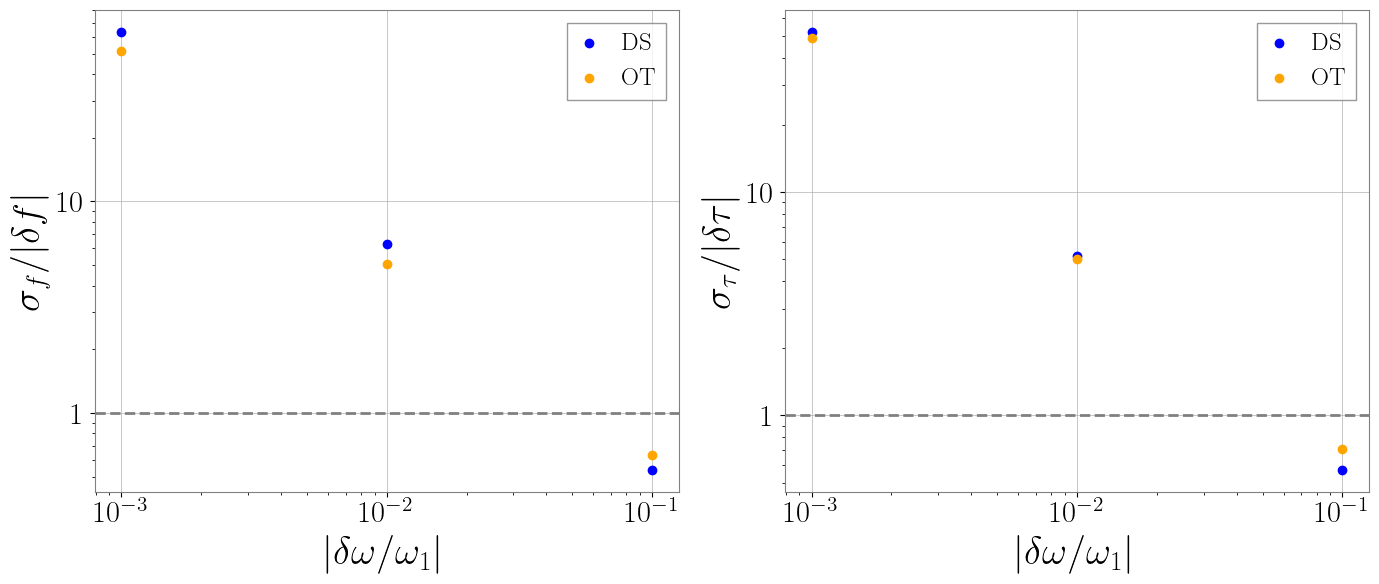

In [20]:
# print(DS_result_list)
# print(OT_result_list)

plt.style.use('~/research/my_plot_style.style')
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# DS_Mirror_dw_over_w1 = [r['dw_over_w1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_resolv_f = [r['resolvability_f'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_resolv_tau = [r['resolvability_tau'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# ax[0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_resolv_f, marker='o', color='blue', label='DS; Mirror')
# ax[1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_resolv_tau, marker='o', color='blue', label='DS; Mirror')

# DS_Heaviside_dw_over_w1 = [r['dw_over_w1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_resolv_f = [r['resolvability_f'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_resolv_tau = [r['resolvability_tau'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# ax[0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_resolv_f, marker='x', color='red', label='DS; Heaviside')
# ax[1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_resolv_tau, marker='x', color='red', label='DS; Heaviside')

# OT_dw_over_w1 = [r['dw_over_w1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_resolv_f = [r['resolvability_f'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_resolv_tau = [r['resolvability_tau'] for r in OT_result_list if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_dw_over_w1, OT_resolv_f, marker='o', color='orange', label='OT')
# ax[1].scatter(OT_dw_over_w1, OT_resolv_tau, marker='o', color='orange', label='OT')

# OT_conditional_resolv_f = [r['resolvability_f'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_resolv_tau = [r['resolvability_tau'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_dw_over_w1, OT_conditional_resolv_f, marker='o', color='purple', label='OT; '+r'$\delta f<0$'+' prior')
# ax[1].scatter(OT_dw_over_w1, OT_conditional_resolv_tau, marker='o', color='purple', label='OT; '+r'$\delta \tau>0$'+' prior')

# OTRA_resolv_f = [r['resolvability_f'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_resolv_tau = [r['resolvability_tau'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_dw_over_w1, OTRA_resolv_f, marker='o', color='green', label='OTRA')
# ax[1].scatter(OT_dw_over_w1, OTRA_resolv_tau, marker='o', color='green', label='OTRA')

# OTRA_delta_f_prior_resolv_f =[r['resolvability_f'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_tau_prior_resolv_tau = [r['resolvability_tau'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# ax[0].scatter(OT_dw_over_w1, OTRA_delta_f_prior_resolv_f, marker='o', color='red', label='OTRA; '+r'$\delta f<0$'+' prior')
# ax[1].scatter(OT_dw_over_w1, OTRA_delta_tau_prior_resolv_tau, marker='o', color='red', label='OTRA; '+r'$\delta \tau>0$'+' prior')

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_resolv_f_pyring = [r['resolvability_f'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_resolv_tau_pyring = [r['resolvability_tau'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(DS_dw_over_w1_pyring, DS_resolv_f_pyring, marker='o', color='blue', label='DS')
ax[1].scatter(DS_dw_over_w1_pyring, DS_resolv_tau_pyring, marker='o', color='blue', label='DS')

OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_resolv_f_pyring = [r['resolvability_f'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_resolv_tau_pyring = [r['resolvability_tau'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
ax[0].scatter(OT_dw_over_w1_pyring, OT_resolv_f_pyring, marker='o', color='orange', label='OT')
ax[1].scatter(OT_dw_over_w1_pyring, OT_resolv_tau_pyring, marker='o', color='orange', label='OT')

ax[0].axhline(y=1, color='gray', linestyle='--')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0].set_ylabel(r'$\sigma_{f} / |\delta f|$')
ax[0].legend()
ax[0].grid(True)

ax[1].axhline(y=1, color='gray', linestyle='--')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1].set_ylabel(r'$\sigma_{\tau} / |\delta \tau|$')
ax[1].legend()
ax[1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

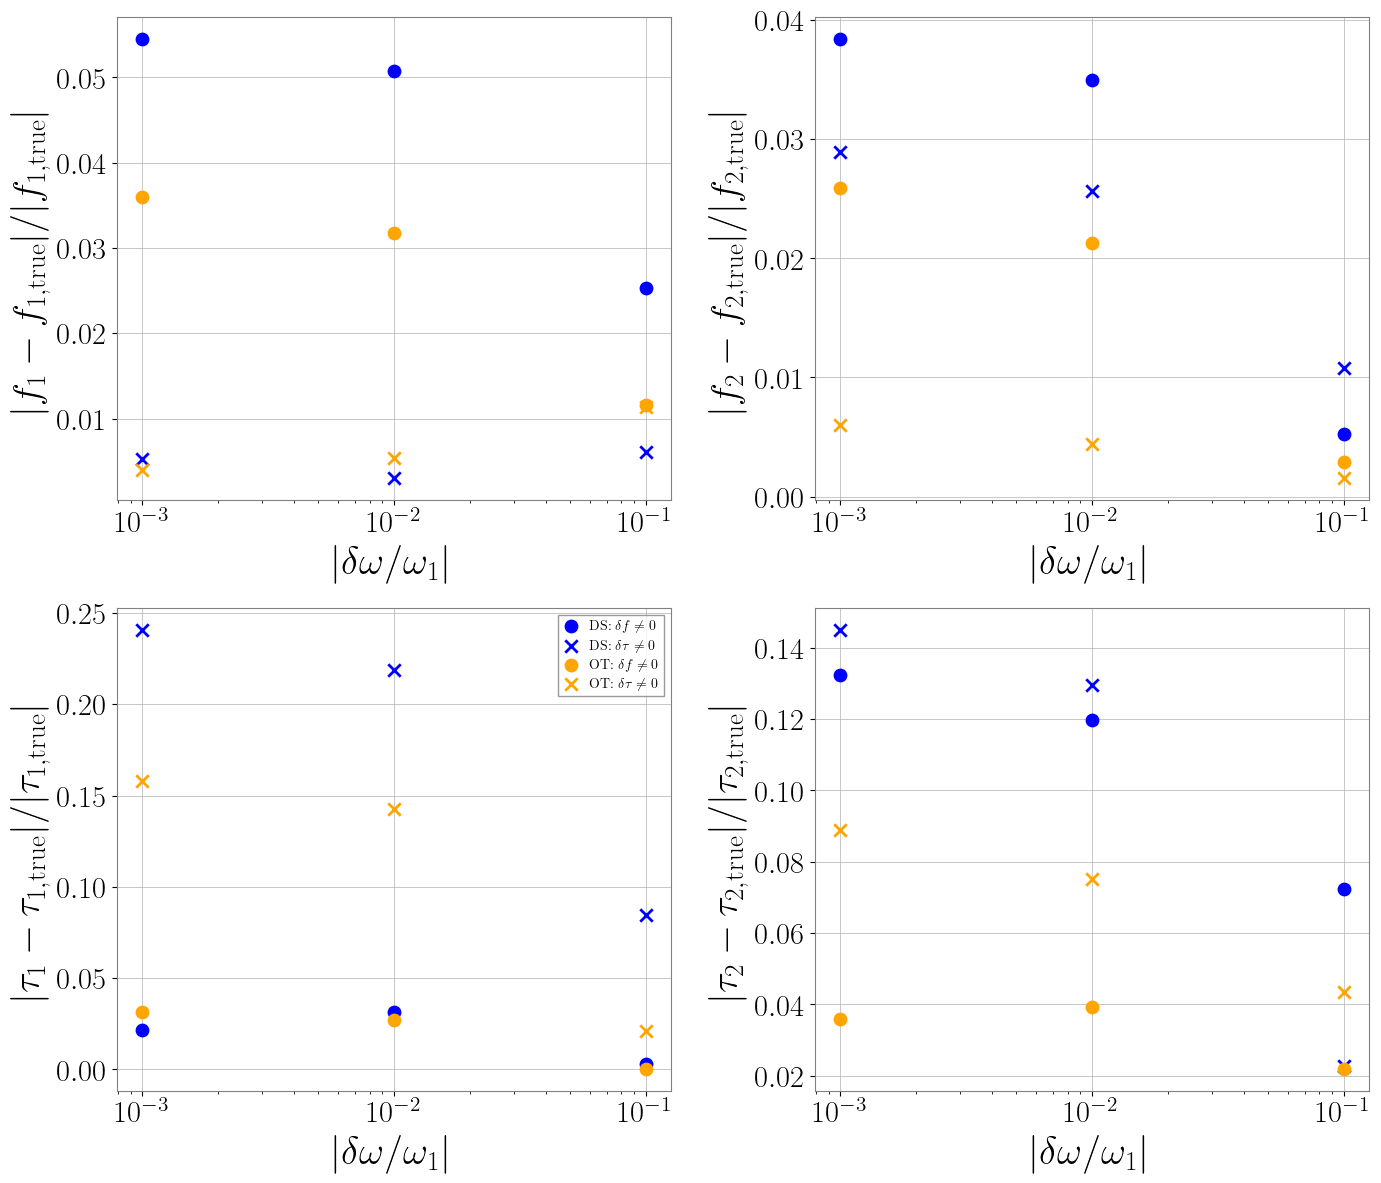

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

# DS_Mirror_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# DS_Mirror_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# DS_Mirror_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# DS_Mirror_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[0, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 0].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 1].scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# DS_Heaviside_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# DS_Heaviside_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# DS_Heaviside_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# DS_Heaviside_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[0, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[0, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 0].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')
# ax[1, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# ax[1, 1].scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# OT_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OT_result_list if r['resolvability_tau'] is not None]
# OT_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OT_result_list if r['resolvability_tau'] is not None]
# OT_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OT_result_list if r['resolvability_tau'] is not None]
# OT_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OT_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[0, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OT_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

# OT_conditional_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# OT_conditional_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# OT_conditional_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# OT_conditional_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OT_condditional_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OT_condditional_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

# OTRA_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# OTRA_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# OTRA_fractional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# OTRA_fractional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f1_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f1_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f2_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_f2_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau1_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau1_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau2_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_fractional_accuracy_tau2_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')

# OTRA_delta_prior_fractional_accuracy_f1_shiftRe = [r['fractional_accuracy_f1'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_prior_fractional_accuracy_f1_shiftIm = [r['fractional_accuracy_f1'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# OTRA_delta_prior_fractional_accuracy_f2_shiftRe = [r['fractional_accuracy_f2'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_prior_fractional_accuracy_f2_shiftIm = [r['fractional_accuracy_f2'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# OTRA_delta_f_prior_resolv_factional_accuracy_tau1_shiftRe = [r['fractional_accuracy_tau1'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_tau_prior_resolv_factional_accuracy_tau1_shiftIm = [r['fractional_accuracy_tau1'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# OTRA_delta_f_prior_resolv_factional_accuracy_tau2_shiftRe = [r['fractional_accuracy_tau2'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_delta_tau_prior_resolv_factional_accuracy_tau2_shiftIm = [r['fractional_accuracy_tau2'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f1_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 0].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f1_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f2_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[0, 1].scatter(OT_dw_over_w1, OTRA_delta_prior_factional_accuracy_f2_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_delta_f_prior_resolv_factional_accuracy_tau1_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 0].scatter(OT_dw_over_w1, OTRA_delta_tau_prior_resolv_factional_accuracy_tau1_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_delta_f_prior_resolv_factional_accuracy_tau2_shiftRe, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# ax[1, 1].scatter(OT_dw_over_w1, OTRA_delta_tau_prior_resolv_factional_accuracy_tau2_shiftIm, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

DS_fractional_accuracy_f1_shiftRe_pyring = [r['fractional_accuracy_f1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_f1_shiftIm_pyring = [r['fractional_accuracy_f1'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
DS_fractional_accuracy_f2_shiftRe_pyring = [r['fractional_accuracy_f2'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_f2_shiftIm_pyring = [r['fractional_accuracy_f2'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
DS_fractional_accuracy_tau1_shiftRe_pyring = [r['fractional_accuracy_tau1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_tau1_shiftIm_pyring = [r['fractional_accuracy_tau1'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
DS_fractional_accuracy_tau2_shiftRe_pyring = [r['fractional_accuracy_tau2'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_tau2_shiftIm_pyring = [r['fractional_accuracy_tau2'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
ax[0, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f1_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[0, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f1_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')
ax[0, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f2_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[0, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_f2_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')
ax[1, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau1_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[1, 0].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau1_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')
ax[1, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau2_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
ax[1, 1].scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_tau2_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')

OT_fractional_accuracy_f1_shiftRe_pyring = [r['fractional_accuracy_f1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_f1_shiftIm_pyring = [r['fractional_accuracy_f1'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
OT_fractional_accuracy_f2_shiftRe_pyring = [r['fractional_accuracy_f2'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_f2_shiftIm_pyring = [r['fractional_accuracy_f2'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
OT_fractional_accuracy_tau1_shiftRe_pyring = [r['fractional_accuracy_tau1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_tau1_shiftIm_pyring = [r['fractional_accuracy_tau1'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
OT_fractional_accuracy_tau2_shiftRe_pyring = [r['fractional_accuracy_tau2'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_tau2_shiftIm_pyring = [r['fractional_accuracy_tau2'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
ax[0, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f1_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[0, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f1_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
ax[0, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f2_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[0, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_f2_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
ax[1, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau1_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[1, 0].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau1_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')
ax[1, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau2_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
ax[1, 1].scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_tau2_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

ax[0, 0].set_xscale('log')
# ax[0, 0].set_yscale('log')
ax[0, 0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0, 0].set_ylabel(r'$|f_{1} - f_{1, \mathrm{true}}| / |f_{1, \mathrm{true}}|$')
# ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].set_xscale('log')
# ax[0, 1].set_yscale('log')
ax[0, 1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[0, 1].set_ylabel(r'$|f_{2} - f_{2, \mathrm{true}}| / |f_{2, \mathrm{true}}|$')
# ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].set_xscale('log')
# ax[1, 0].set_yscale('log')
ax[1, 0].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1, 0].set_ylabel(r'$|\tau_{1} - \tau_{1, \mathrm{true}}| / |\tau_{1, \mathrm{true}}|$')
ax[1, 0].legend(fontsize=10)
ax[1, 0].grid(True)

ax[1, 1].set_xscale('log')
# ax[1, 1].set_yscale('log')
ax[1, 1].set_xlabel(r'$|\delta\omega / \omega_{1}|$')
ax[1, 1].set_ylabel(r'$|\tau_{2} - \tau_{2, \mathrm{true}}| / |\tau_{2, \mathrm{true}}|$')
# ax[1, 1].legend()
ax[1, 1].grid(True)

for _ax in ax.flatten():
    _ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

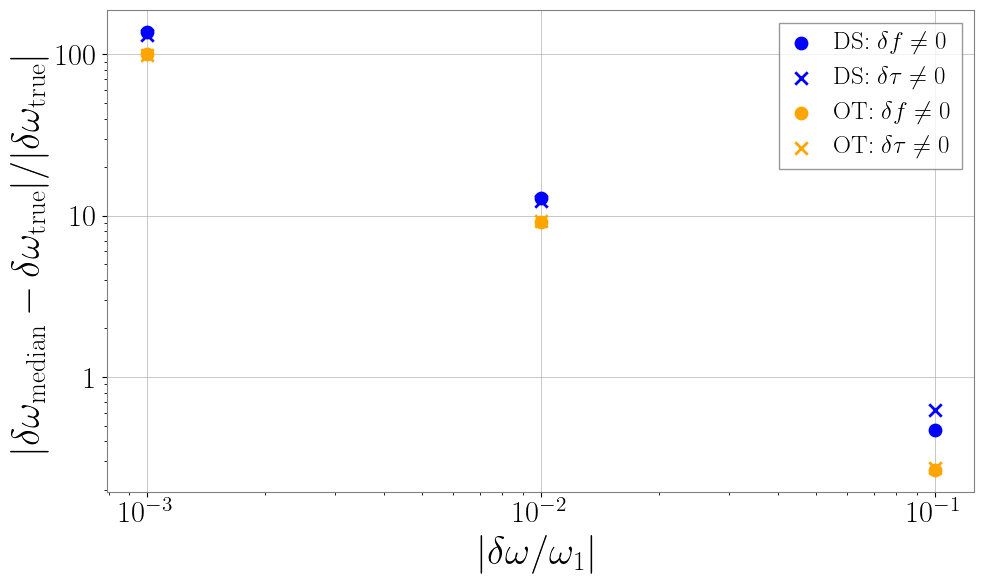

In [21]:
plt.figure()

# DS_Mirror_dw_over_w1 = [r['dw_over_w1'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in DS_Mirror_result_list if r['resolvability_f'] is not None]
# DS_Mirror_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in DS_Mirror_result_list if r['resolvability_tau'] is not None]
# plt.scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='blue', label='DS: Mirror, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# plt.scatter(DS_Mirror_dw_over_w1, DS_Mirror_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='blue', label='DS: Mirror, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# DS_Heaviside_dw_over_w1 = [r['dw_over_w1'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in DS_Heaviside_result_list if r['resolvability_f'] is not None]
# DS_Heaviside_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in DS_Heaviside_result_list if r['resolvability_tau'] is not None]
# plt.scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='red', label='DS: Heaviside, '+r'$\delta f \ne 0$, $\delta \tau = 0$')
# plt.scatter(DS_Heaviside_dw_over_w1, DS_Heaviside_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='red', label='DS: Heaviside, '+r'$\delta f = 0$, $\delta \tau \ne 0$')

# OT_dw_over_w1 = [r['dw_over_w1'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in OT_result_list if r['resolvability_f'] is not None]
# OT_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in OT_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OT_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
# plt.scatter(OT_dw_over_w1, OT_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

# OT_conditional_fractional_accuracy_f = [r['fractional_accuracy_dw'] for r in OT_conditional_result_list if r['resolvability_f'] is not None]
# OT_conditional_fractional_accuracy_tau = [r['fractional_accuracy_dw'] for r in OT_conditional_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_f, marker='o', s=80, color='purple', label='OT: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# plt.scatter(OT_dw_over_w1, OT_conditional_fractional_accuracy_tau, marker='x', s=80, color='purple', label='OT: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

# OTRA_fractional_accuracy_dw_shiftRe = [r['fractional_accuracy_dw'] for r in OTRA_result_list if r['resolvability_f'] is not None]
# OTRA_fractional_accuracy_dw_shiftIm = [r['fractional_accuracy_dw'] for r in OTRA_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OTRA_fractional_accuracy_dw_shiftRe, marker='o', s=80, color='green', label='OTRA: '+r'$\delta f \ne 0$')
# plt.scatter(OT_dw_over_w1, OTRA_fractional_accuracy_dw_shiftIm, marker='x', s=80, color='green', label='OTRA: '+r'$\delta \tau \ne 0$')

# OTRA_conditional_fractional_accuracy_f =[r['fractional_accuracy_dw'] for r in OTRA_conditional_result_list if r['resolvability_f'] is not None]
# OTRA_conditional_fractional_accuracy_tau = [r['fractional_accuracy_dw'] for r in OTRA_conditional_result_list if r['resolvability_tau'] is not None]
# plt.scatter(OT_dw_over_w1, OTRA_conditional_fractional_accuracy_f, marker='o', s=80, color='red', label='OTRA: '+r'$\delta f \ne 0$'+', '+r'$\delta f<0$'+' prior')
# plt.scatter(OT_dw_over_w1, OTRA_conditional_fractional_accuracy_tau, marker='x', s=80, color='red', label='OTRA: '+r'$\delta \tau \ne 0$'+', '+r'$\delta \tau>0$'+' prior')

DS_dw_over_w1_pyring = [r['dw_over_w1'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_dw_shiftRe_pyring = [r['fractional_accuracy_dw'] for r in DS_result_list_pyring if r['resolvability_f'] is not None]
DS_fractional_accuracy_dw_shiftIm_pyring = [r['fractional_accuracy_dw'] for r in DS_result_list_pyring if r['resolvability_tau'] is not None]
plt.scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_dw_shiftRe_pyring, marker='o', s=80, color='blue', label='DS: '+r'$\delta f \ne 0$')
plt.scatter(DS_dw_over_w1_pyring, DS_fractional_accuracy_dw_shiftIm_pyring, marker='x', s=80, color='blue', label='DS: '+r'$\delta \tau \ne 0$')

OT_dw_over_w1_pyring = [r['dw_over_w1'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_dw_shiftRe_pyring = [r['fractional_accuracy_dw'] for r in OT_result_list_pyring if r['resolvability_f'] is not None]
OT_fractional_accuracy_dw_shiftIm_pyring = [r['fractional_accuracy_dw'] for r in OT_result_list_pyring if r['resolvability_tau'] is not None]
plt.scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_dw_shiftRe_pyring, marker='o', s=80, color='orange', label='OT: '+r'$\delta f \ne 0$')
plt.scatter(OT_dw_over_w1_pyring, OT_fractional_accuracy_dw_shiftIm_pyring, marker='x', s=80, color='orange', label='OT: '+r'$\delta \tau \ne 0$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$|\delta\omega / \omega_{1}|$')
plt.ylabel(r'$|\delta \omega_{\mathrm{median}} - \delta \omega_{\mathrm{true}}| / |\delta \omega_{\mathrm{true}}|$')
plt.legend()
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()